In [23]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

In [24]:
# Load Titanic dataset
df = sns.load_dataset('titanic')

In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [26]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [27]:
# Prepare data: Predict survival
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()

In [28]:
# Encode sex: male=1, female=0
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

In [29]:
# Features and target
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

In [30]:
print(f"Total samples: {len(df)}")
print(f"Survived: {sum(y==1)}, Died: {sum(y==0)}")
print(df.head())

Total samples: 714
Survived: 290, Died: 424
   survived  pclass  sex   age     fare
0         0       3    1  22.0   7.2500
1         1       1    0  38.0  71.2833
2         1       3    0  26.0   7.9250
3         1       1    0  35.0  53.1000
4         0       3    1  35.0   8.0500


In [31]:
# Split and train model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [32]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [34]:
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")

Training: 499, Testing: 215


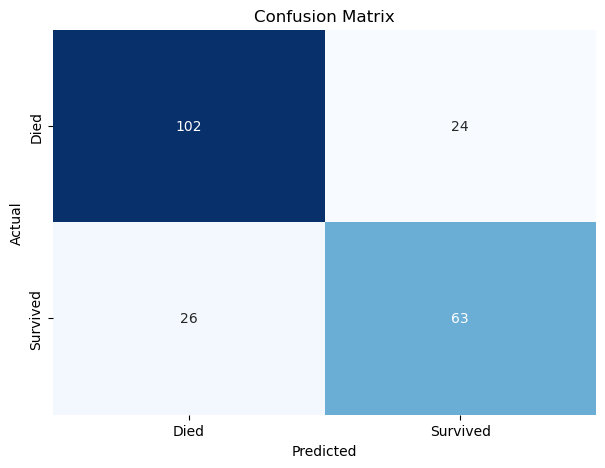

[[102  24]
 [ 26  63]]


In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(cm)

In [36]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Metrics:")
print("="*40)
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

Metrics:
Accuracy:  0.767
Precision: 0.724
Recall:    0.708
F1-Score:  0.716


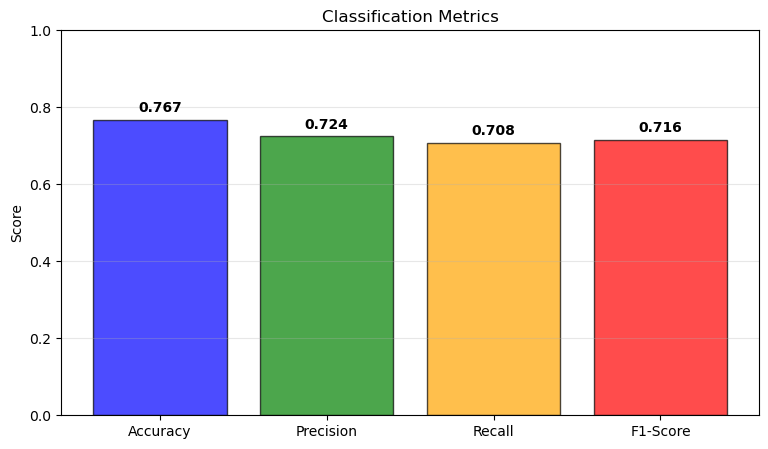

In [37]:
# Visualize metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, scores, color=['blue', 'green', 'orange', 'red'], 
               edgecolor='black', alpha=0.7)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, 
             f'{score:.3f}', ha='center', fontweight='bold')
plt.show()

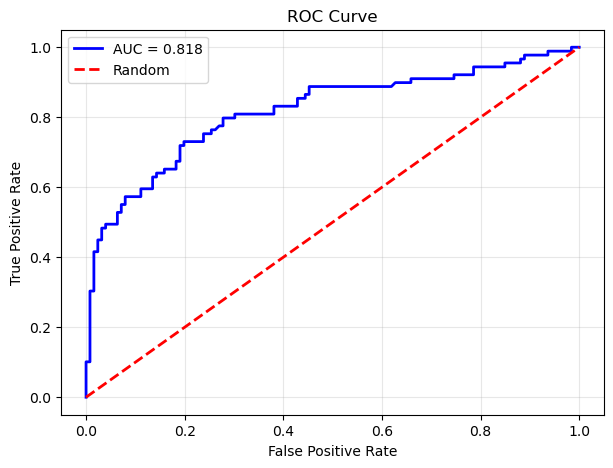

AUC-ROC: 0.818


In [38]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC-ROC: {roc_auc:.3f}")

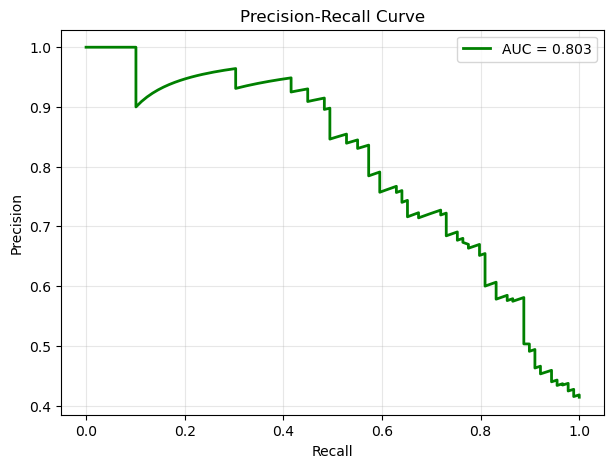

PR-AUC: 0.803


In [39]:
# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, 'g-', linewidth=2, label=f'AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"PR-AUC: {pr_auc:.3f}")

In [40]:
# Test different thresholds
def evaluate_threshold(y_true, y_proba, threshold):
    y_pred_new = (y_proba >= threshold).astype(int)
    prec = precision_score(y_true, y_pred_new)
    rec = recall_score(y_true, y_pred_new)
    f1 = f1_score(y_true, y_pred_new)
    return prec, rec, f1

print("Threshold Impact:")
print("="*50)
for threshold in [0.3, 0.5, 0.7]:
    prec, rec, f1 = evaluate_threshold(y_test, y_proba, threshold)
    print(f"Threshold {threshold}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

Threshold Impact:
Threshold 0.3: Precision=0.664, Recall=0.798, F1=0.724
Threshold 0.5: Precision=0.724, Recall=0.708, F1=0.716
Threshold 0.7: Precision=0.863, Recall=0.494, F1=0.629


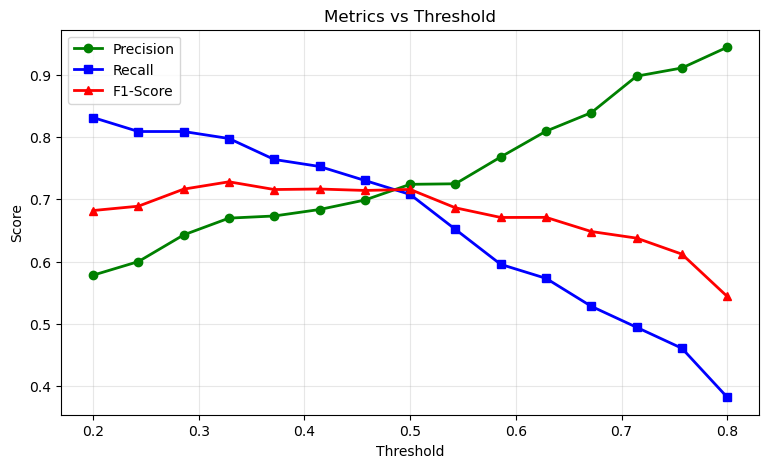

In [41]:
# Visualize threshold impact
thresholds = np.linspace(0.2, 0.8, 15)
precisions, recalls, f1_scores = [], [], []

for threshold in thresholds:
    prec, rec, f1 = evaluate_threshold(y_test, y_proba, threshold)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, 'g-', linewidth=2, marker='o', label='Precision')
plt.plot(thresholds, recalls, 'b-', linewidth=2, marker='s', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, marker='^', label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

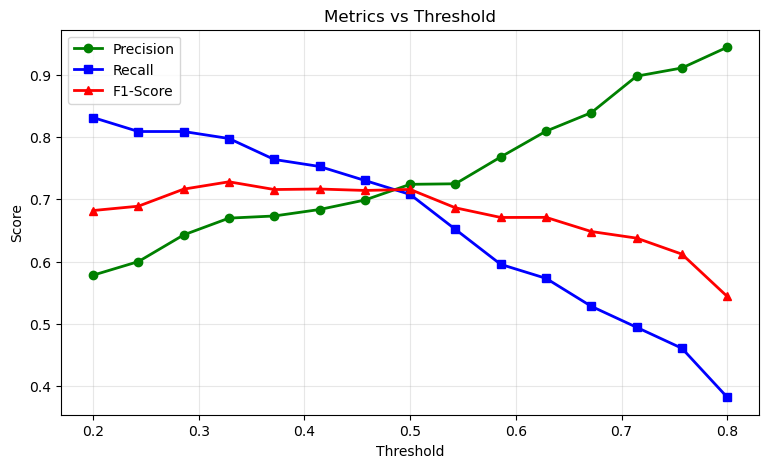

In [42]:
# Visualize threshold impact
thresholds = np.linspace(0.2, 0.8, 15)
precisions, recalls, f1_scores = [], [], []

for threshold in thresholds:
    prec, rec, f1 = evaluate_threshold(y_test, y_proba, threshold)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, 'g-', linewidth=2, marker='o', label='Precision')
plt.plot(thresholds, recalls, 'b-', linewidth=2, marker='s', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, marker='^', label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()